In [1]:
import tensorflow as tf
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.utils import class_weight
import numpy as np
import time
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import VGG16

In [2]:
 

# List all physical devices
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print("GPU is available!")
    print("GPU devices:", gpus)
else:
    print("GPU is NOT available. Using CPU.")


GPU is available!
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Found 9959 images belonging to 4 classes.
Found 2487 images belonging to 4 classes.
Class Weights: {0: 0.8388645552560647, 1: 0.6129369768586903, 2: 2.259301270417423, 3: 1.3627531472359058}
Epoch 1/20
312/312 [==============================] - 157s 463ms/step - loss: 0.8597 - accuracy: 0.6601 - val_loss: 0.8517 - val_accuracy: 0.6663
Epoch 2/20
312/312 [==============================] - 43s 138ms/step - loss: 0.3202 - accuracy: 0.8959 - val_loss: 0.6784 - val_accuracy: 0.7242
Epoch 3/20
312/312 [==============================] - 44s 142ms/step - loss: 0.1455 - accuracy: 0.9602 - val_loss: 0.6127 - val_accuracy: 0.7435
Epoch 4/20
312/312 [==============================] - 43s 138ms/step - loss: 0.0818 - accuracy: 0.9804 - val_loss: 0.5093 - val_accuracy: 0.8058
Epoch 5/20
312/312 [==============================] - 43s 137ms/step - loss: 0.0497 - accuracy: 0.9898 - val_loss: 0.5818 - val_accuracy: 0.7519
Epoch 6/20
312/312 [==============================] - 43s 137ms/step - loss: 0.0302

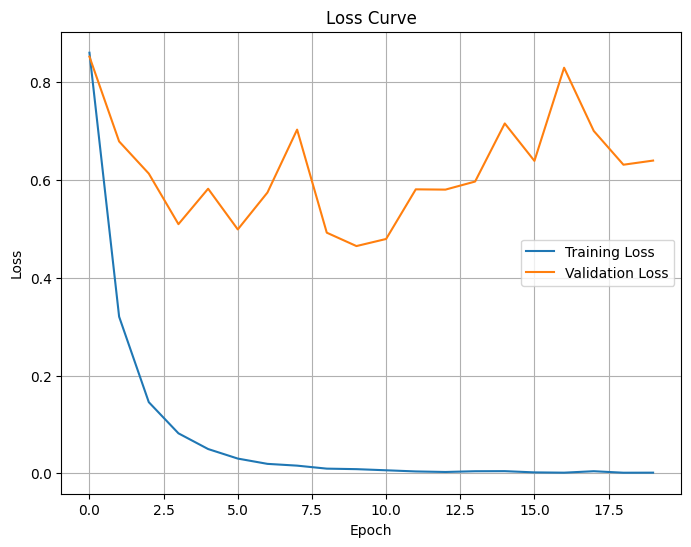

78/78 [==============================] - 8s 96ms/step


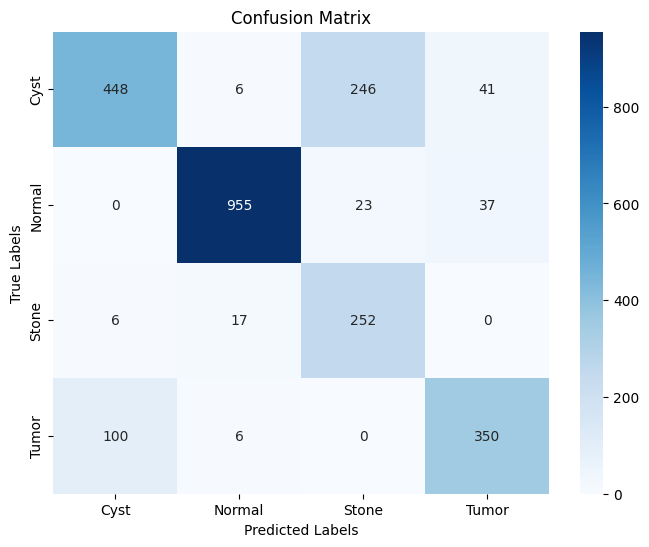

Training Time: 974.58 seconds
Testing Time: 7.81 seconds
Confusion Matrix:
 [[448   6 246  41]
 [  0 955  23  37]
 [  6  17 252   0]
 [100   6   0 350]]
Classification Report:
               precision    recall  f1-score   support

        Cyst       0.81      0.60      0.69       741
      Normal       0.97      0.94      0.96      1015
       Stone       0.48      0.92      0.63       275
       Tumor       0.82      0.77      0.79       456

    accuracy                           0.81      2487
   macro avg       0.77      0.81      0.77      2487
weighted avg       0.84      0.81      0.81      2487

Overall Accuracy: 0.8062
Accuracy for class 'Cyst': 0.6046
Accuracy for class 'Normal': 0.9409
Accuracy for class 'Stone': 0.9164
Accuracy for class 'Tumor': 0.7675


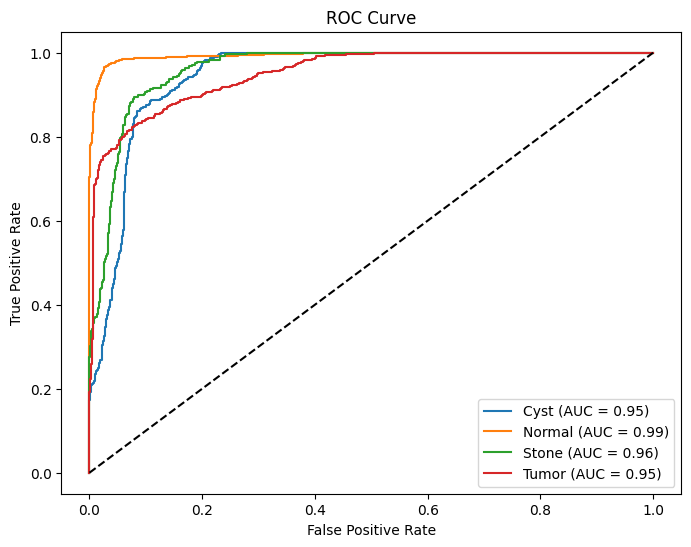

Overall Accuracy: 80.62%
Precision: 77.02%
Recall: 80.73%
F1-Score: 76.81%


In [3]:
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = 4
EPOCHS = 20
DATASET_PATH = "CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone"
 
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_generator = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)
y_train = train_generator.classes

weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(weights))

print("Class Weights:", class_weights)
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)


base_model.trainable = True

for layer in base_model.layers[:-4]:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
outputs = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=outputs)


model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

start_train_time = time.time()

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS
)

plt.figure(figsize=(8,6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()
plt.grid(True)
plt.show()

training_time = time.time() - start_train_time

start_test_time = time.time()

y_pred_prob = model.predict(val_generator)
y_pred_classes = np.argmax(y_pred_prob, axis=1)
y_true = val_generator.classes

testing_time = time.time() - start_test_time
class_names = list(val_generator.class_indices.keys())
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

class_report = classification_report(y_true, y_pred_classes, target_names=list(val_generator.class_indices.keys()))
accuracy = np.sum(y_pred_classes == y_true) / len(y_true)
print(f"Training Time: {training_time:.2f} seconds")
print(f"Testing Time: {testing_time:.2f} seconds")
print("Confusion Matrix:\n", cm)
print("Classification Report:\n", class_report)
print(f"Overall Accuracy: {accuracy:.4f}")
class_accuracy = cm.diagonal() / cm.sum(axis=1)
for i, class_name in enumerate(val_generator.class_indices.keys()):
    print(f"Accuracy for class '{class_name}': {class_accuracy[i]:.4f}")
y_true_onehot = to_categorical(y_true, num_classes=NUM_CLASSES)

plt.figure(figsize=(8, 6))
for i, class_name in enumerate(val_generator.class_indices.keys()):
    fpr, tpr, _ = roc_curve(y_true_onehot[:, i], y_pred_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_name} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()


accuracy = np.sum(y_pred_classes == y_true) / len(y_true)


precision = precision_score(y_true, y_pred_classes, average='macro')
recall = recall_score(y_true, y_pred_classes, average='macro')
f1 = f1_score(y_true, y_pred_classes, average='macro')

print(f"Overall Accuracy: {accuracy*100:.2f}%")
print(f"Precision: {precision*100:.2f}%")
print(f"Recall: {recall*100:.2f}%")
print(f"F1-Score: {f1*100:.2f}%")